# 📱 Exploratory Data Analysis: Smartphone Market Dataset

**Goal:** Understand what actually drives smartphone pricing and specs across the Indian e-commerce market — brand positioning, hardware trends, and which features correlate with price — through univariate and bivariate analysis, followed by a first pass at cleaning the data for modeling.

| | |
|---|---|
| **Dataset** | `smartphone_cleaned_v5.csv` — 980 smartphones, 25 features |
| **Techniques** | Univariate & bivariate EDA, skewness/outlier analysis, KNN imputation, one-hot encoding |
| **Tools** | Python · Pandas · NumPy · Matplotlib · Seaborn · Scikit-learn |
| **Part of** | [`data-analysis`](https://github.com/Divya-Chital27/data-analysis) repository |

---

## 📑 Table of Contents
1. [Setup & Data Loading](#1)
2. [First Look at the Data](#2)
3. [Univariate Analysis](#3)
   - 3.1 [Brand Name](#3-1)
   - 3.2 [Price](#3-2)
   - 3.3 [Rating](#3-3)
   - 3.4 [Connectivity & Hardware Features](#3-4)
   - 3.5 [Numeric Feature Distributions](#3-5)
4. [Bivariate Analysis](#4)
5. [Handling Missing Values — KNN Imputation](#5)
6. [Encoding Categorical Variables](#6)
7. [Key Insights & Summary](#7)
8. [Related Projects](#8)

---


<a id="1"></a>
## 1. Setup & Data Loading

We start by importing the core data-analysis stack — **Pandas** and **NumPy** for data manipulation, and **Matplotlib**/**Seaborn** for visualization — then configure Pandas to display every column and row so nothing gets truncated while exploring a wide, 25-column dataset.

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
pd.set_option('display.max_columns',None)
pd.set_option('display.max_rows',None)

Loading the cleaned smartphone dataset into a DataFrame.

In [ ]:
df=pd.read_csv('/content/smartphone_cleaned_v5.csv')

<a id="2"></a>
## 2. First Look at the Data

Before diving into analysis, let's inspect the structure: what columns exist, their data types, and how many values are missing in each.

In [ ]:
df.head()

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
0,oneplus,OnePlus 11 5G,54999,89.0,True,True,False,snapdragon,8.0,3.2,5000.0,1,100.0,12,256,6.70,120,1440 x 3216,3,1.0,android,50.0,16.0,0,NaN
1,oneplus,OnePlus Nord CE 2 Lite 5G,19989,81.0,True,False,False,snapdragon,8.0,2.2,5000.0,1,33.0,6,128,6.59,120,1080 x 2412,3,1.0,android,64.0,16.0,1,1024.0
2,samsung,Samsung Galaxy A14 5G,16499,75.0,True,False,False,exynos,8.0,2.4,5000.0,1,15.0,4,64,6.60,90,1080 x 2408,3,1.0,android,50.0,13.0,1,1024.0
3,motorola,Motorola Moto G62 5G,14999,81.0,True,False,False,snapdragon,8.0,2.2,5000.0,1,NaN,6,128,6.55,120,1080 x 2400,3,1.0,android,50.0,16.0,1,1024.0
4,realme,Realme 10 Pro Plus,24999,82.0,True,False,False,dimensity,8.0,2.6,5000.0,1,67.0,6,128,6.70,120,1080 x 2412,3,1.0,android,108.0,16.0,0,NaN


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 980 entries, 0 to 979
Data columns (total 25 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   brand_name                 980 non-null    object 
 1   model                      980 non-null    object 
 2   price                      980 non-null    int64  
 3   rating                     879 non-null    float64
 4   has_5g                     980 non-null    bool   
 5   has_nfc                    980 non-null    bool   
 6   has_ir_blaster             980 non-null    bool   
 7   processor_brand            960 non-null    object 
 8   num_cores                  974 non-null    float64
 9   processor_speed            938 non-null    float64
 10  battery_capacity           969 non-null    float64
 11  fast_charging_available    980 non-null    int64  
 12  fast_charging              769 non-null    float64
 13  ram_capacity               980 non-null    int64  

**Dataset snapshot:**
- **980 rows × 25 columns** — one row per smartphone listing
- Mix of categorical (`brand_name`, `processor_brand`, `os`), boolean (`has_5g`, `has_nfc`, `has_ir_blaster`), and numeric (`price`, `rating`, `battery_capacity`, `processor_speed`, ...) features
- Several columns (`rating`, `processor_brand`, `num_cores`, `processor_speed`) already show missing values here — these are revisited in [Section 5](#5).

<a id="3"></a>
## 3. Univariate Analysis

We look at each feature in isolation first — its distribution, spread, and data quality — before comparing features against each other in [Section 4](#4).

<a id="3-1"></a>
### 3.1 Brand Name

How concentrated is the market? A bar chart shows the top 10 brands by listing count, and a pie chart shows their relative market share.

In [ ]:
df['brand_name'].value_counts()

,count
brand_name,
xiaomi,134
samsung,132
vivo,111
realme,97
oppo,88
motorola,52
apple,46
oneplus,42
poco,41


<Axes: xlabel='brand_name'>

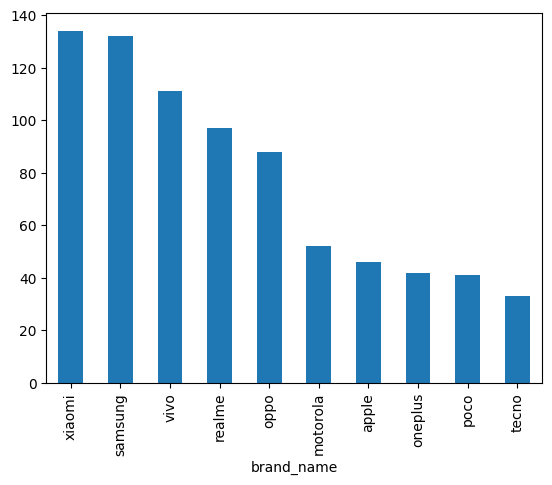

In [ ]:
df['brand_name'].value_counts().head(10).plot(kind='bar')

<Axes: ylabel='count'>

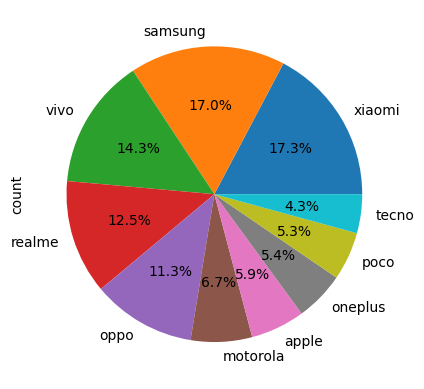

In [ ]:
df['brand_name'].value_counts().head(10).plot(kind='pie',autopct='%0.1f%%')

In [ ]:
df.brand_name.isnull().sum()

np.int64(0)

**Insight:** Xiaomi (134), Samsung (132), and Vivo (111) are the three most-listed brands, together accounting for roughly a third of the dataset. `brand_name` has **zero missing values**, so it's fully reliable for grouping and comparison.

`model` is too granular (near-unique per row) to analyze directly, so it's excluded from further analysis — we confirm that below.

In [ ]:
#model- Nothing can be done on this
df.model.nunique()

980

<a id="3-2"></a>
### 3.2 Price

`price` is the target variable of interest — most other features will eventually be compared against it in the bivariate section.

In [ ]:
df.price.describe()

,price
count,980.000000
mean,32520.504082
std,39531.812669
min,3499.000000
25%,12999.000000
50%,19994.500000
75%,35491.500000
max,650000.000000


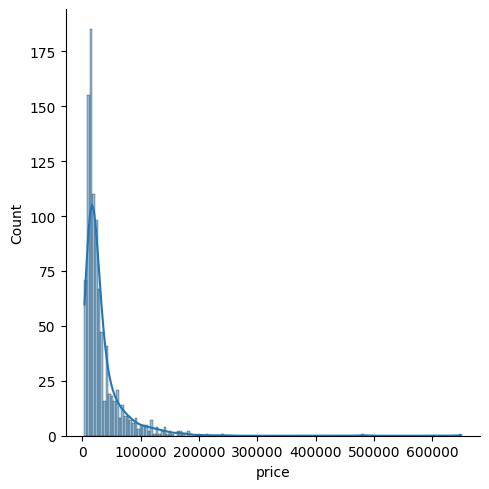

In [ ]:
sns.displot(kind='hist',data=df,x='price',kde=True)

In [ ]:
df.price.skew()#not normal

np.float64(6.591790999665567)

<Axes: ylabel='price'>

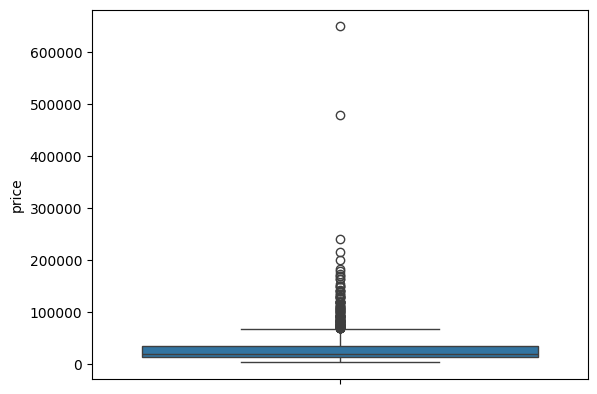

In [ ]:
sns.boxplot(df['price'])

In [ ]:
df[df['price']>200000]#outliers we will need to remove those

,brand_name,model,price,rating,has_5g,has_nfc,has_ir_blaster,processor_brand,num_cores,processor_speed,battery_capacity,fast_charging_available,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,os,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto
427,vertu,Vertu Signature Touch,650000,62.0,False,True,False,snapdragon,8.0,1.50,2275.0,0,NaN,2,64,4.70,60,1080 x 1920,1,1.0,android,13.0,2.1,0,NaN
478,huawei,Huawei Mate 50 RS Porsche Design,239999,81.0,False,True,True,snapdragon,8.0,3.20,4700.0,1,66.0,12,512,6.74,120,1212 x 2616,3,1.0,other,50.0,13.0,1,256.0
887,xiaomi,Xiaomi Redmi K20 Pro Signature Edition,480000,88.0,False,True,False,snapdragon,8.0,2.80,4000.0,1,27.0,8,256,6.39,60,1080 x 2340,3,1.0,android,48.0,20.0,0,NaN
951,huawei,Huawei Mate 30 RS Porsche Design,214990,NaN,True,True,True,kirin,8.0,2.86,4500.0,1,NaN,12,512,6.53,60,1176 x 2400,4,2.0,android,40.0,32.0,1,256.0


In [ ]:
df.price.isnull().sum()

np.int64(0)

**Conclusions:**
- Average price is **₹32,520**, but the **median is only ₹19,994** — a large gap that signals the distribution is heavily right-skewed (confirmed by a skewness of **6.59**).
- A handful of ultra-premium listings (e.g., the **Vertu Signature Touch at ₹6,50,000**, and Porsche Design editions from Huawei) sit far above the rest of the market and show up as clear **outliers** above ₹2,00,000.
- `price` has **no missing values**, so no imputation is needed here — but the skew means log-transformation or outlier capping would help if this feature is later used in a model.

<a id="3-3"></a>
### 3.3 Rating

Next, `rating` — a 0–100 quality score assigned to each phone.

In [ ]:
df.rating.describe()

,rating
count,879.000000
mean,78.258248
std,7.402854
min,60.000000
25%,74.000000
50%,80.000000
75%,84.000000
max,89.000000


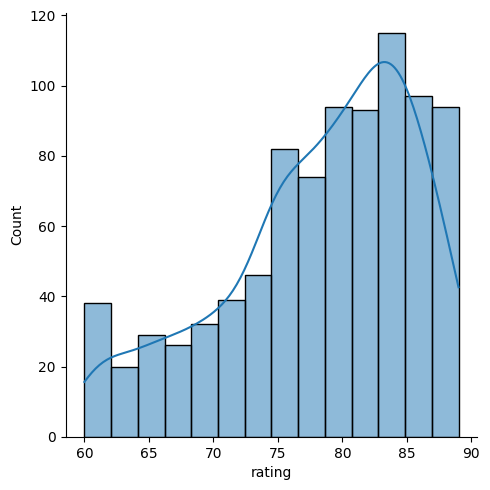

In [ ]:
sns.displot(kind='hist',data=df,x='rating',kde=True)

In [ ]:
df.rating.skew()

np.float64(-0.6989993034105535)

<Axes: ylabel='rating'>

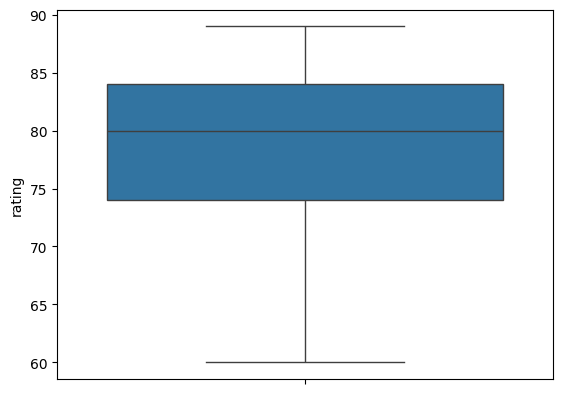

In [ ]:
sns.boxplot(df['rating'])

In [ ]:
df.rating.isnull().sum()/980

np.float64(0.10306122448979592)

**Conclusions:**
- Ratings are mildly **left-skewed** (skewness ≈ **-0.70**), meaning most phones cluster toward higher scores (mean ≈ 78, median 80) with a longer tail toward lower ratings.
- No significant outliers.
- **~10.3% of ratings are missing** (101 of 980 rows) — one of the columns handled later via KNN imputation in [Section 5](#5).

<a id="3-4"></a>
### 3.4 Connectivity & Hardware Features

A quick sweep across the remaining categorical/boolean specs — connectivity (5G, NFC, IR blaster), processor details, charging, memory, display, camera count, and OS — using pie charts to read each feature's overall split at a glance.

<Axes: ylabel='count'>

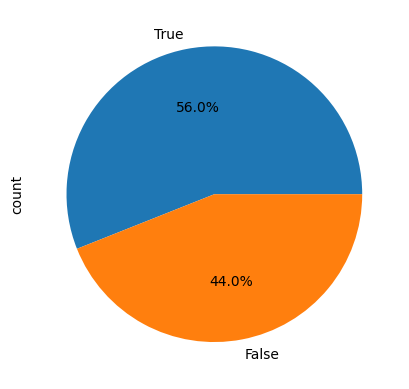

In [ ]:
#has_5g
df.has_5g.value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

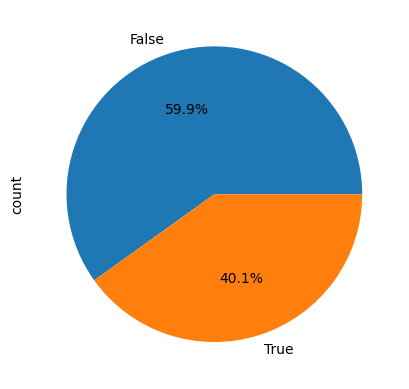

In [ ]:
df.has_nfc.value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

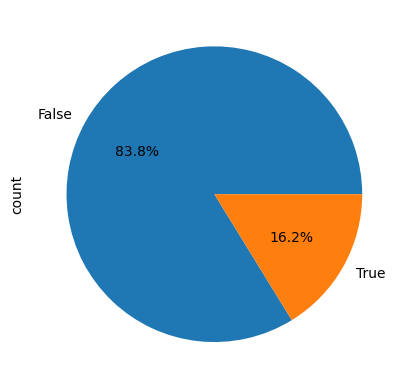

In [ ]:
df.has_ir_blaster.value_counts().plot(kind='pie',autopct='%0.1f%%')#mostly chinnesse phones has ir blasters


**Note:** IR blasters are disproportionately common on Chinese smartphone brands (Xiaomi, Infinix, Tecno), which explains the skew in this feature's distribution.

<Axes: ylabel='count'>

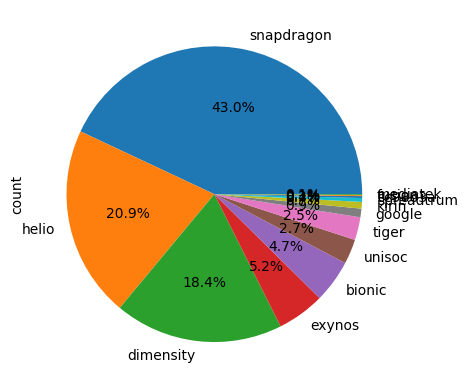

In [ ]:
df.processor_brand.value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

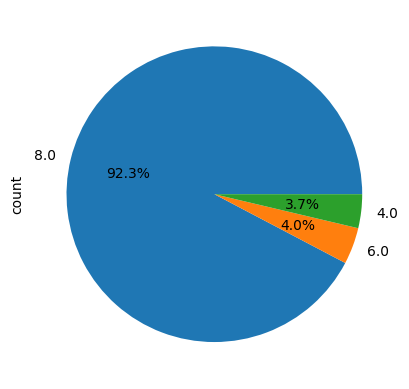

In [ ]:
df.num_cores.value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

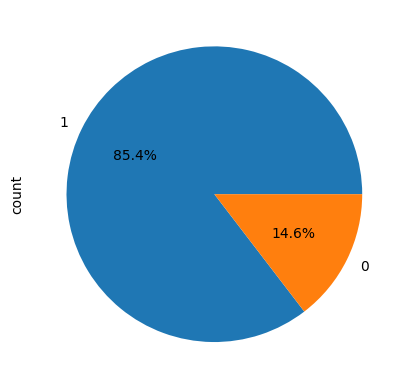

In [ ]:
df.fast_charging_available.value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

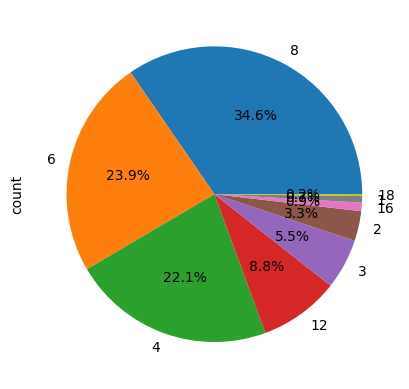

In [ ]:
df.ram_capacity.value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

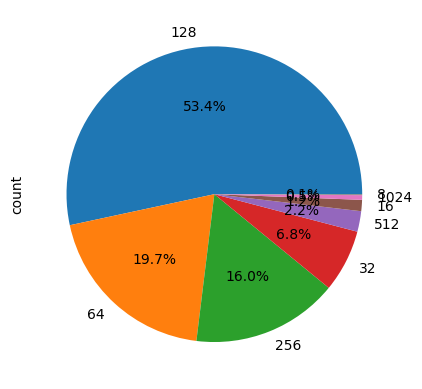

In [ ]:
df.internal_memory.value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

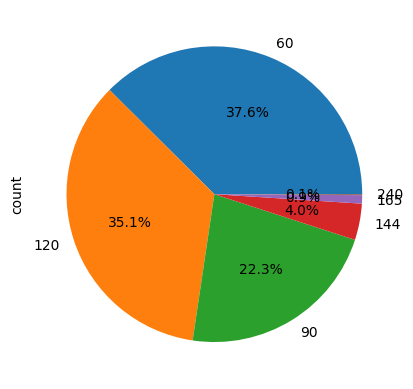

In [ ]:
df.refresh_rate.value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

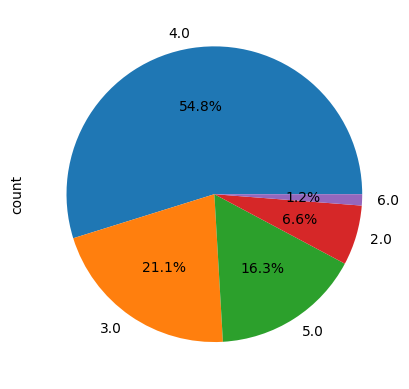

In [ ]:
(df['num_rear_cameras']+df['num_front_cameras']).value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

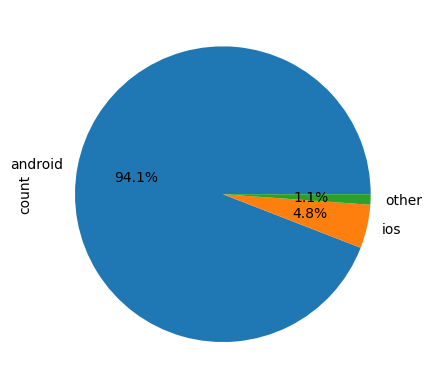

In [ ]:
df.os.value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

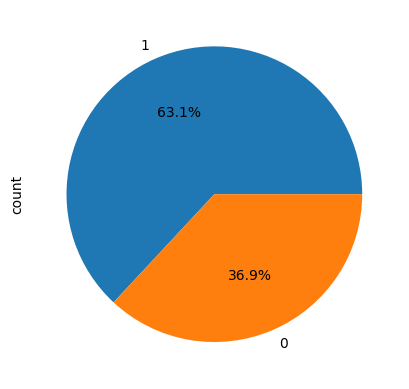

In [ ]:
df.extended_memory_available.value_counts().plot(kind='pie',autopct='%0.1f%%')

<Axes: ylabel='count'>

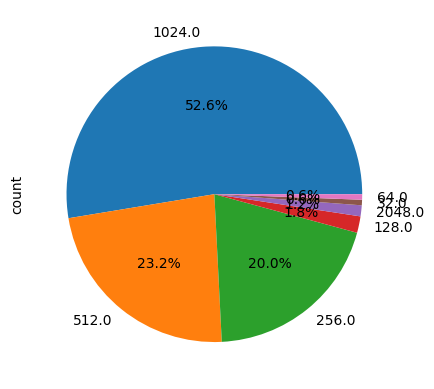

In [ ]:
df.extended_upto.value_counts().plot(kind='pie',autopct='%0.1f%%')

<a id="3-5"></a>
### 3.5 Numeric Feature Distributions

Rather than repeat the same histogram + boxplot code for every remaining numeric column, we define a small reusable helper and loop it across all numeric features (battery capacity, processor speed, screen size, RAM, etc.) to scan for skew and outliers in one pass.

In [ ]:
def plot_graphs(column_name):
  sns.displot(kind='hist',kde=True,data=df,x=column_name,label=column_name)
  sns.catplot(data=df[column_name],kind='box')


In [ ]:
columns=df.select_dtypes(include=['float64','int64']).iloc[:,[3,4,6,9,13,14,16]].columns

In [ ]:
columns

Index(['processor_speed', 'battery_capacity', 'fast_charging', 'screen_size',
       'primary_camera_rear', 'primary_camera_front', 'extended_upto'],
      dtype='object')

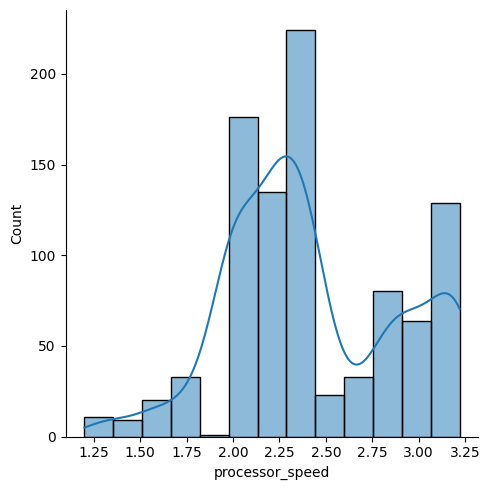

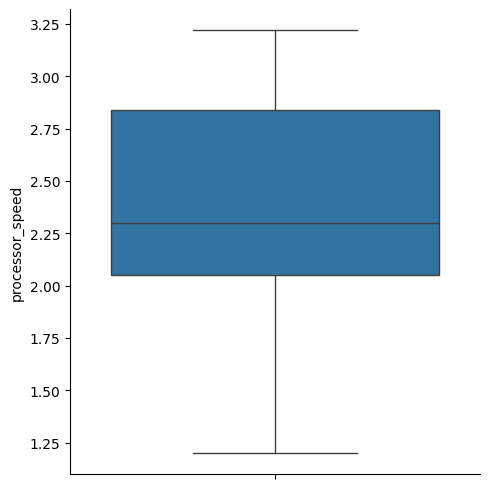

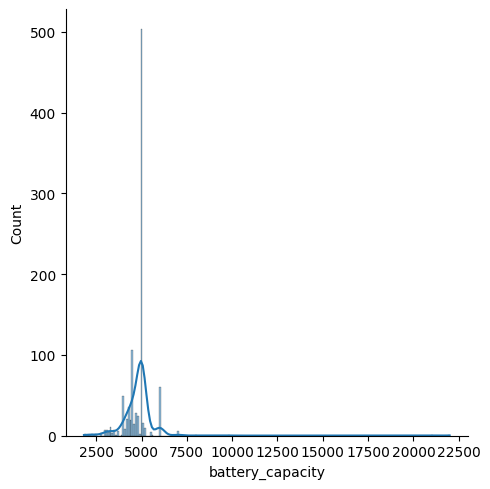

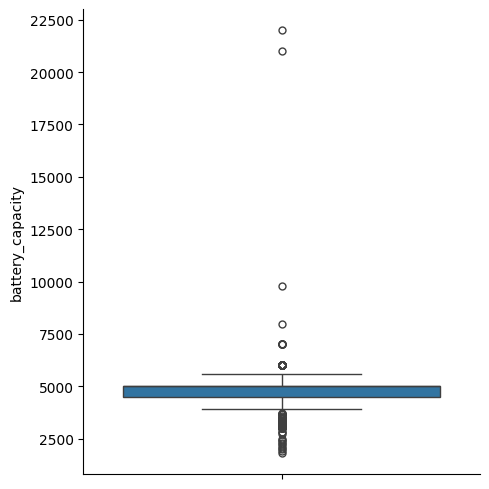

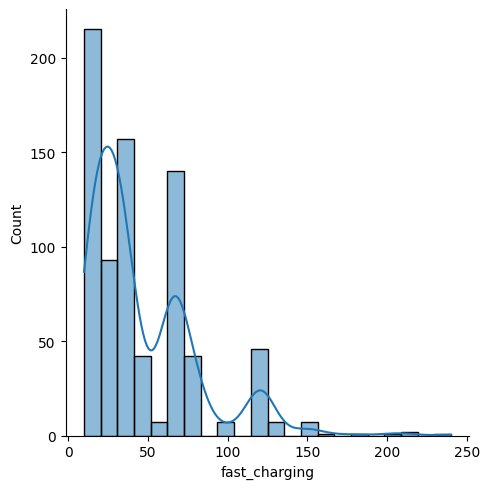

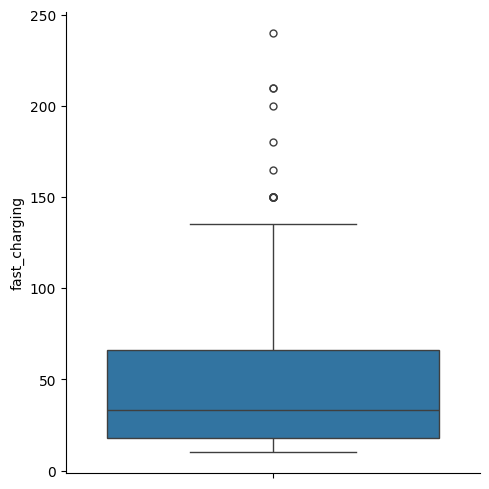

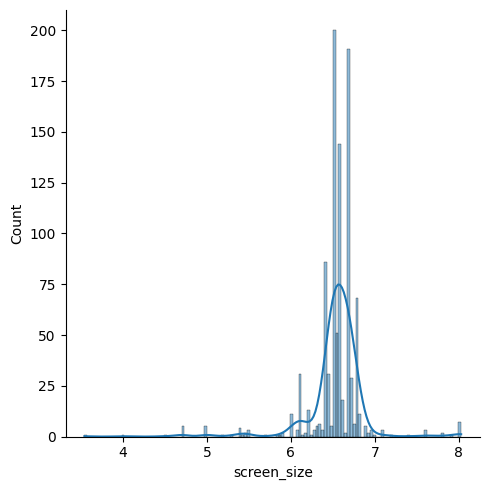

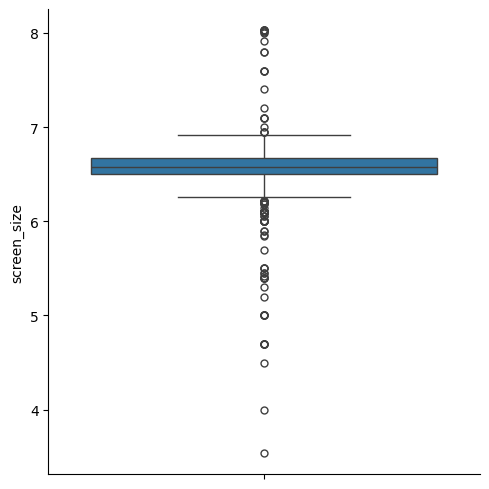

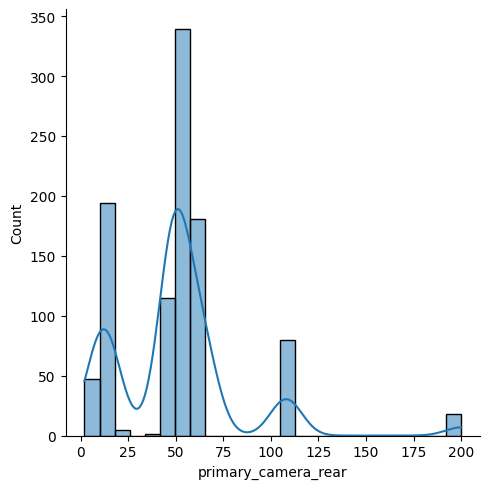

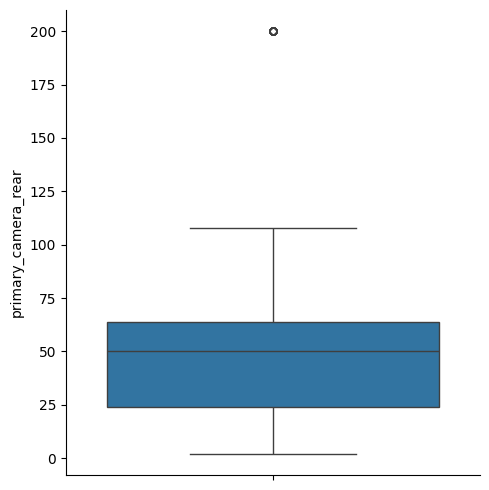

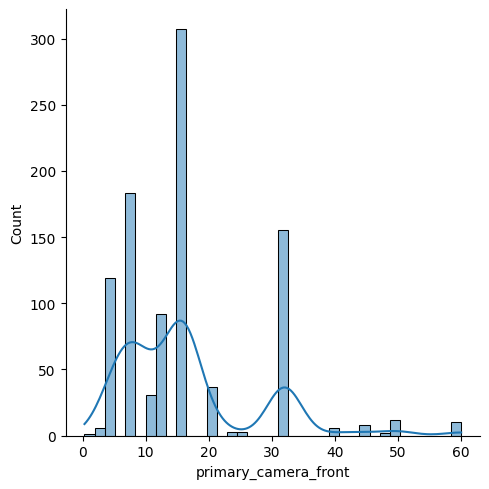

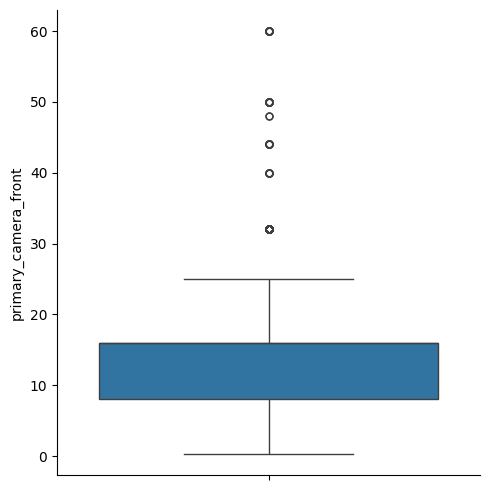

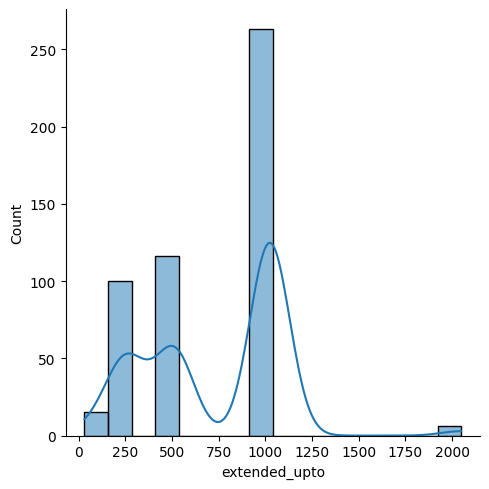

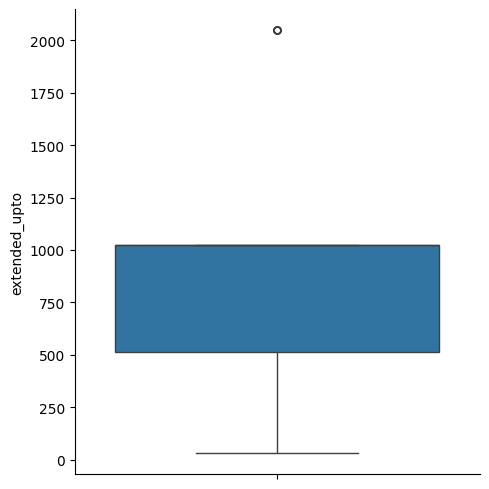

In [ ]:
for col in columns:
  plot_graphs(col)

<a id="4"></a>
## 4. Bivariate Analysis

With each feature understood on its own, the next question is: **what actually moves the price?** We compare `price` against brand, rating, connectivity, and processor features to separate the specs that matter from the ones that don't.

**Brand vs. Price** — does the brand itself carry a price premium?

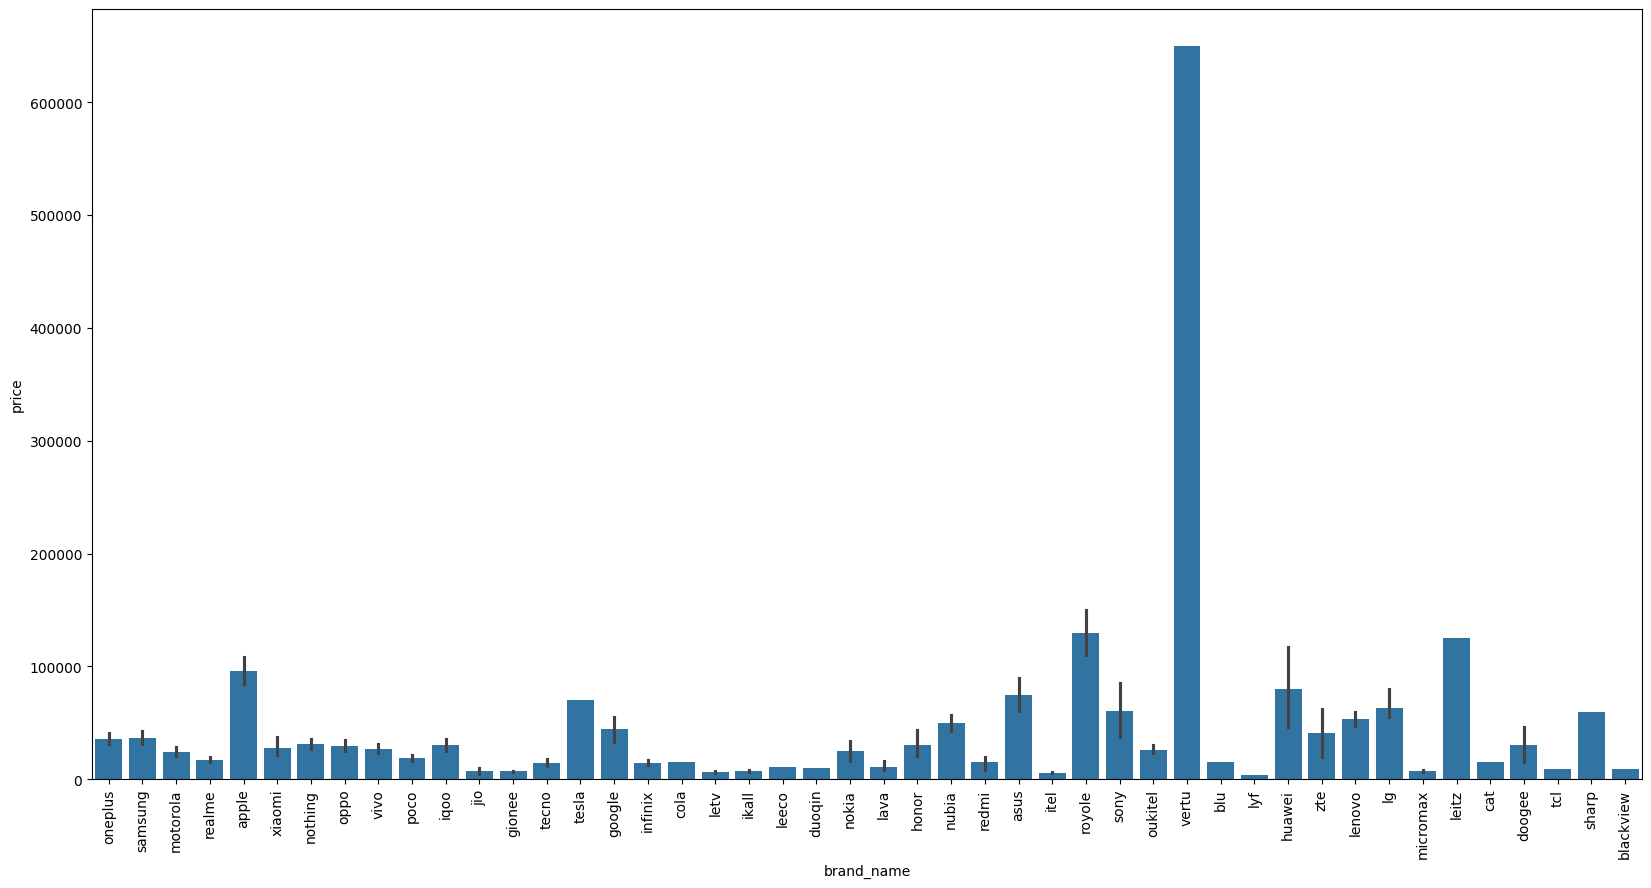

In [ ]:
plt.figure(figsize=(20,10))
sns.barplot(data=df,x='brand_name',y='price')
plt.xticks(rotation='vertical')
plt.show()

In [ ]:
x=df.groupby('brand_name').count()['model']

In [ ]:
temp_df=df[df.brand_name.isin(x[x>10].index)]

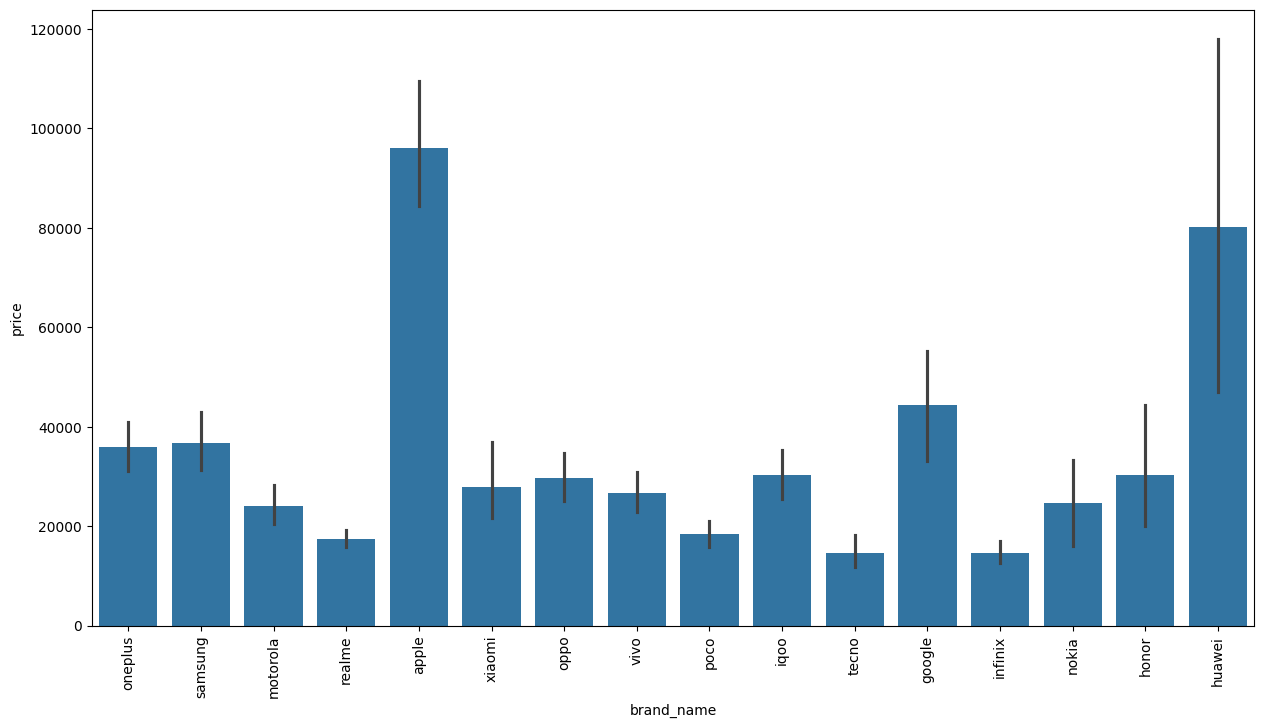

In [ ]:
#brandname is affecting the price
plt.figure(figsize=(15,8))
sns.barplot(data=temp_df,x='brand_name',y='price')
plt.xticks(rotation='vertical')
plt.show()

**Insight:** Brand clearly affects price — after filtering out brands with fewer than 10 listings (to avoid noise from one-off luxury entries), premium brands like Apple and Vertu still separate cleanly from budget-focused brands like Itel and Lava.

**Rating vs. Price** — do better-rated phones cost more?

<Axes: xlabel='rating', ylabel='price'>

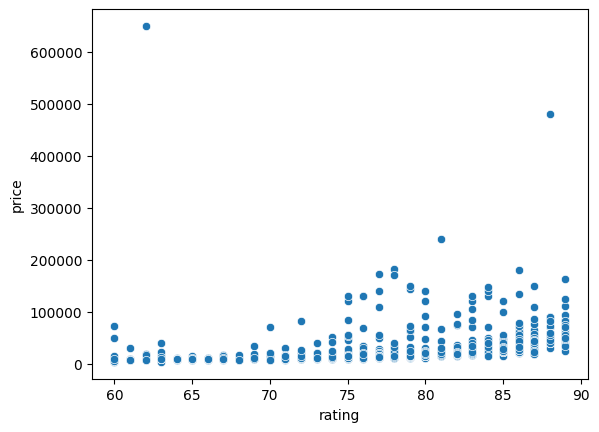

In [ ]:
sns.scatterplot(data=df,x='rating',y='price')#price is not strongly dependent on rating

**Insight:** Price is **not strongly dependent on rating** — the scatter shows high-rated phones across almost every price band, suggesting rating reflects user satisfaction more than positioning or cost.

**Connectivity Features vs. Price** — do 5G, NFC, or IR blaster support command a price premium?

<Axes: xlabel='has_5g', ylabel='price'>

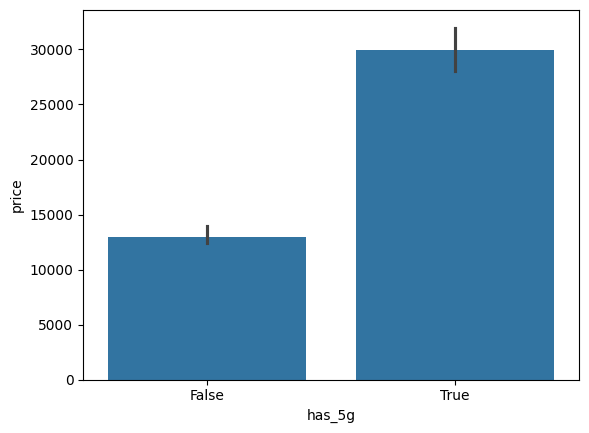

In [ ]:
sns.barplot(data=temp_df,x='has_5g',y='price',estimator=np.median)

<Axes: xlabel='has_nfc', ylabel='price'>

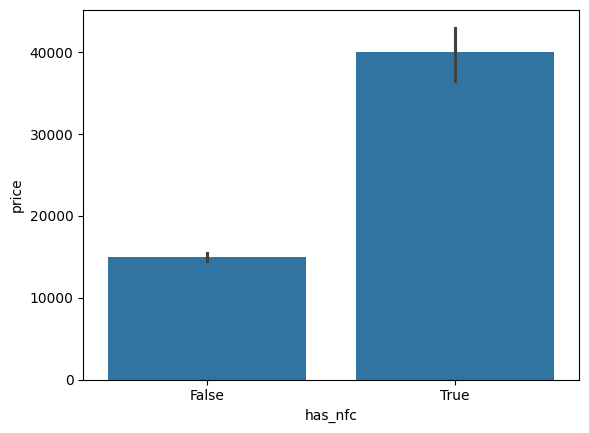

In [ ]:
sns.barplot(data=temp_df,x='has_nfc',y='price',estimator=np.median)

<Axes: xlabel='has_ir_blaster', ylabel='price'>

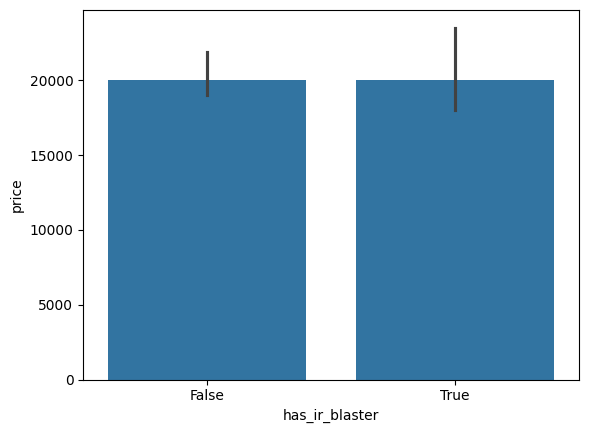

In [ ]:
sns.barplot(data=temp_df,x='has_ir_blaster',y='price',estimator=np.median)#irblaster col does not affect much price column

**Insight:** 5G and NFC support are both associated with meaningfully higher median prices, while the IR blaster has little effect on price — it's more of a regional/brand convention (see [3.4](#3-4)) than a premium feature.

**Processor vs. Price**

([0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12],
 [Text(0, 0, 'snapdragon'),
  Text(1, 0, 'exynos'),
  Text(2, 0, 'dimensity'),
  Text(3, 0, 'bionic'),
  Text(4, 0, 'helio'),
  Text(5, 0, 'unisoc'),
  Text(6, 0, 'google'),
  Text(7, 0, 'tiger'),
  Text(8, 0, 'sc9863a'),
  Text(9, 0, 'fusion'),
  Text(10, 0, 'kirin'),
  Text(11, 0, 'spreadtrum'),
  Text(12, 0, 'mediatek')])

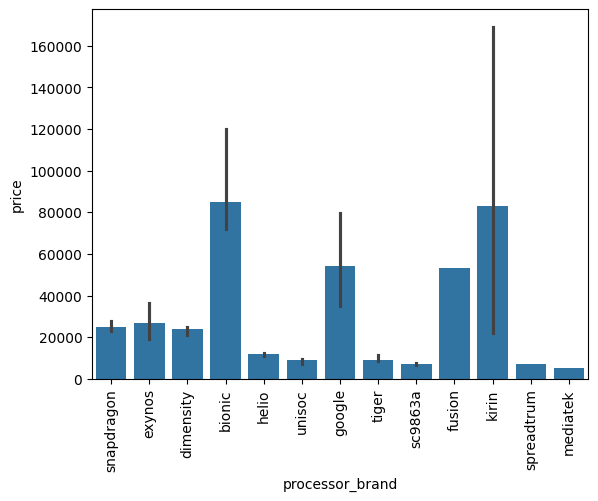

In [ ]:
sns.barplot(data=temp_df,x='processor_brand',y='price',estimator=np.median)
plt.xticks(rotation='vertical')

<Axes: xlabel='num_cores', ylabel='price'>

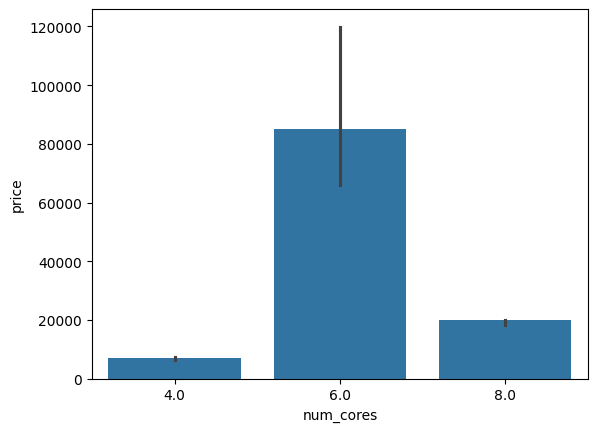

In [ ]:
sns.barplot(data=temp_df,x='num_cores',y='price',estimator=np.median)#6 core is lot as mostly apple phones are hexacore

In [ ]:
pd.crosstab(df['num_cores'],df['os'])

os,android,ios,other
num_cores,,,
4.0,33,1,1
6.0,0,39,0
8.0,875,1,10


**Insight:** The crosstab confirms *why* 6-core processors show a high median price in the chart above — hexa-core chips are used almost exclusively by iOS devices (39 of 40 six-core phones run iOS), so this isn't really a "6-core premium," it's an Apple premium.

**Processor Speed & Screen Size vs. Price**

<Axes: xlabel='processor_speed', ylabel='price'>

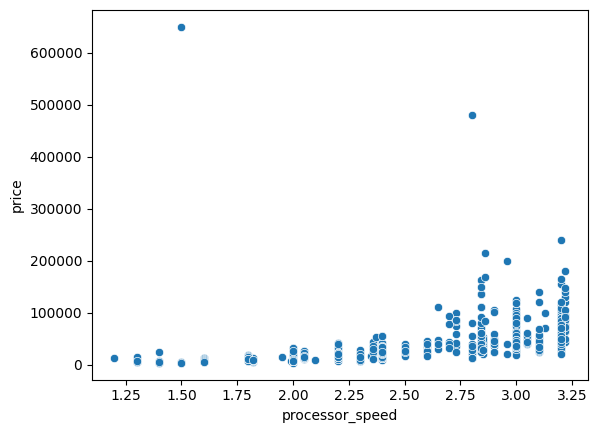

In [ ]:
sns.scatterplot(data=df,x='processor_speed',y='price')

<Axes: xlabel='screen_size', ylabel='price'>

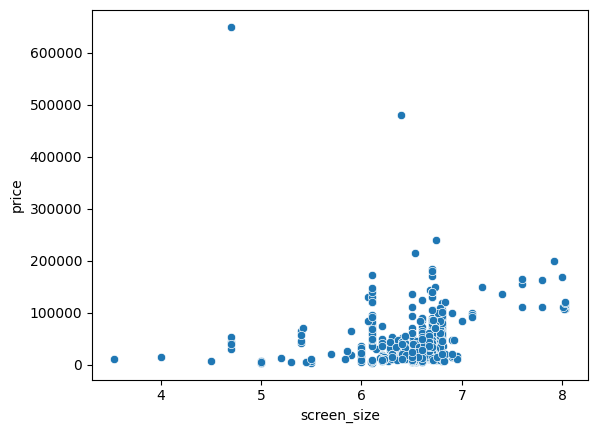

In [ ]:
sns.scatterplot(data=df,x='screen_size',y='price')

<a id="5"></a>
## 5. Handling Missing Values — KNN Imputation

Several numeric columns (`rating`, `num_cores`, `processor_speed`, etc.) have missing values, as seen in [Section 2](#2). Rather than dropping rows or filling with a simple mean, we use **K-Nearest Neighbors (KNN) Imputation**, which estimates each missing value using the 5 most similar rows (by their other numeric features) — a more context-aware fill than a flat average.

In [ ]:
#knn imputer for filling missing values
df.shape

(980, 25)

In [ ]:
x_df=df.select_dtypes(include=['int64','float64']).head().drop(columns='price')

In [ ]:
from sklearn.impute import KNNImputer
imputer=KNNImputer(n_neighbors=5)


In [ ]:
x_df_values=imputer.fit_transform(x_df)

In [ ]:
x_df=pd.DataFrame(x_df_values,columns=x_df.columns)

In [ ]:
x_df['price']=df['price']

In [ ]:
x_df.shape

(5, 17)

`price` is deliberately excluded from the imputer's input features and only re-attached afterward, since it's the target variable — we don't want it influencing how missing values in other columns get estimated.

<a id="6"></a>
## 6. Encoding Categorical Variables

Most machine learning models need numeric input, so categorical columns (`brand_name`, `processor_brand`, `os`) are converted using **one-hot encoding**. `drop_first=True` removes one category per feature to avoid the dummy variable trap (multicollinearity).

In [ ]:
#one hot encoding
pd.get_dummies(df,columns=['brand_name','processor_brand','os'],drop_first=True).head()

,model,price,rating,has_5g,has_nfc,has_ir_blaster,num_cores,processor_speed,battery_capacity,fast_charging_available,fast_charging,ram_capacity,internal_memory,screen_size,refresh_rate,resolution,num_rear_cameras,num_front_cameras,primary_camera_rear,primary_camera_front,extended_memory_available,extended_upto,brand_name_asus,brand_name_blackview,brand_name_blu,brand_name_cat,brand_name_cola,brand_name_doogee,brand_name_duoqin,brand_name_gionee,brand_name_google,brand_name_honor,brand_name_huawei,brand_name_ikall,brand_name_infinix,brand_name_iqoo,brand_name_itel,brand_name_jio,brand_name_lava,brand_name_leeco,brand_name_leitz,brand_name_lenovo,brand_name_letv,brand_name_lg,brand_name_lyf,brand_name_micromax,brand_name_motorola,brand_name_nokia,brand_name_nothing,brand_name_nubia,brand_name_oneplus,brand_name_oppo,brand_name_oukitel,brand_name_poco,brand_name_realme,brand_name_redmi,brand_name_royole,brand_name_samsung,brand_name_sharp,brand_name_sony,brand_name_tcl,brand_name_tecno,brand_name_tesla,brand_name_vertu,brand_name_vivo,brand_name_xiaomi,brand_name_zte,processor_brand_dimensity,processor_brand_exynos,processor_brand_fusion,processor_brand_google,processor_brand_helio,processor_brand_kirin,processor_brand_mediatek,processor_brand_sc9863a,processor_brand_snapdragon,processor_brand_spreadtrum,processor_brand_tiger,processor_brand_unisoc,os_ios,os_other
0,OnePlus 11 5G,54999,89.0,True,True,False,8.0,3.2,5000.0,1,100.0,12,256,6.70,120,1440 x 3216,3,1.0,50.0,16.0,0,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
1,OnePlus Nord CE 2 Lite 5G,19989,81.0,True,False,False,8.0,2.2,5000.0,1,33.0,6,128,6.59,120,1080 x 2412,3,1.0,64.0,16.0,1,1024.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
2,Samsung Galaxy A14 5G,16499,75.0,True,False,False,8.0,2.4,5000.0,1,15.0,4,64,6.60,90,1080 x 2408,3,1.0,50.0,13.0,1,1024.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False
3,Motorola Moto G62 5G,14999,81.0,True,False,False,8.0,2.2,5000.0,1,NaN,6,128,6.55,120,1080 x 2400,3,1.0,50.0,16.0,1,1024.0,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False
4,Realme 10 Pro Plus,24999,82.0,True,False,False,8.0,2.6,5000.0,1,67.0,6,128,6.70,120,1080 x 2412,3,1.0,108.0,16.0,0,NaN,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False


<a id="7"></a>
## 7. Key Insights & Summary

- **Market is brand-concentrated:** Xiaomi, Samsung, and Vivo alone account for ~38% of all listings.
- **Price is heavily right-skewed** (skew ≈ 6.59): median price (₹19,994) sits far below the mean (₹32,520) because of a small number of ultra-premium outliers (up to ₹6.5L).
- **Rating is mildly left-skewed** (skew ≈ -0.70) with ~10.3% missing values — most phones are rated fairly well, with a long tail of weaker performers.
- **Rating is a weak price predictor**, but **5G and NFC support correlate with higher prices**, while the **IR blaster is a brand convention** (mostly Chinese OEMs), not a price driver.
- **The "6-core premium" is really an Apple premium** — nearly all hexa-core phones in the dataset run iOS.
- **Missing numeric values were imputed with KNN** (not mean/median), preserving relationships between correlated features like `processor_speed` and `battery_capacity`.
- **Categorical features were one-hot encoded** to prepare the dataset for downstream modeling (e.g., a future price-prediction model).

**Possible next steps:** build a regression model to predict `price` from these features, or cluster phones into market segments (budget / mid-range / flagship) using the cleaned, encoded dataset.

<a id="8"></a>
## 8. Related Projects

This notebook is part of my broader data analysis portfolio:

- 📊 [**Online Courses Analysis**](https://github.com/Divya-Chital27/Online-Courses-Analysis-PowerBI) — Power BI dashboard on 8,000+ online courses
- 🛒 [**Customer Shopping Behavior Analysis**](https://github.com/Divya-Chital27/customer-shopping-behavior-analysis) — end-to-end EDA + Power BI on 3,900 retail customers
- 🏬 [**Vrinda Store Sales Analysis**](https://github.com/Divya-Chital27/Vrinda-Store-Sales-Analysis) — Excel-based analysis of 31,000+ retail orders
- 📁 [**data-analysis**](https://github.com/Divya-Chital27/data-analysis) — the parent repository for this notebook
